<a href="https://colab.research.google.com/github/byeasmin/full_stack_dataScience_ML_DL_AI/blob/main/Assignments/assignment-04_Clean-tranformn-EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading**

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Basic Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [8]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


# **Target Variable Distribution**

In [9]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


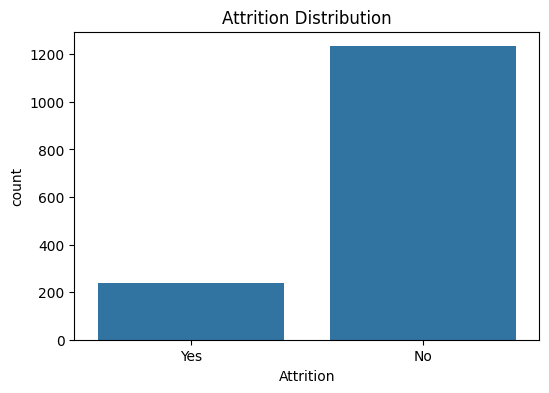

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition',data=df)

plt.title("Attrition Distribution")
plt.show()

#### Most employees stayed with the company, while a smaller portion left.

# **Data Quality Checks**

In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


##### No missing values detected.

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [14]:
df['EmployeeCount'].value_counts()
df['Over18'].value_counts()
df['StandardHours'].value_counts()

,count
StandardHours,
80,1470


# **Data Cleaning**

In [15]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols,inplace=True)

In [16]:
print(df.shape)

(1470, 31)


# **Exploratory Data Analysis**

#### Visualization 1

##### **Age** **Distribution**

##### The age distribution is concentrated between 30 and 40 years. This indicates that most employees are in the middle stage of their careers. Very young and very old employees represent a smaller portion of the workforce.

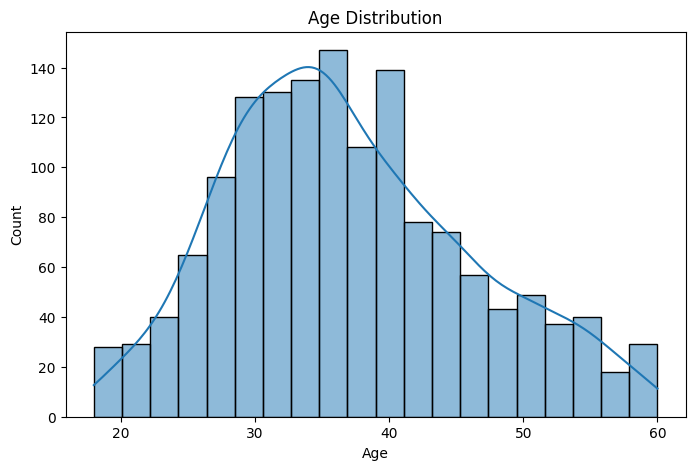

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=20,kde=True)

plt.title("Age Distribution")
plt.show()

#### Visualization 2

##### **Monthly** **Income** **Distribution**

##### The income distribution is positively skewed, indicating that most employees earn moderate salaries while a smaller group earns significantly higher incomes.


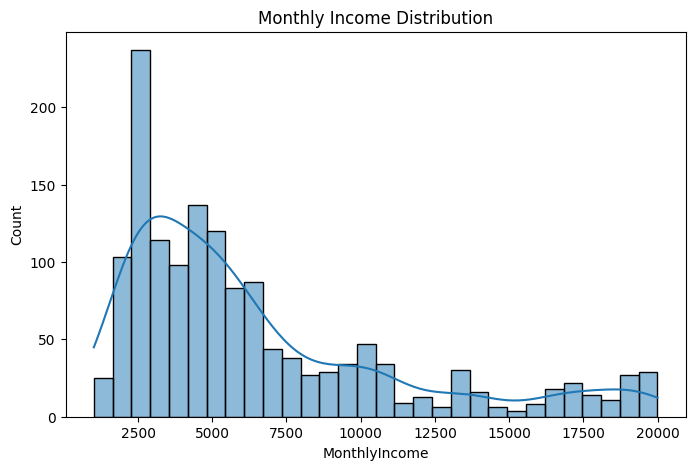

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyIncome'],bins=30,kde=True)

plt.title("Monthly Income Distribution")
plt.show()

#### Visualization 3

##### **Department Distribution**
##### Research & Development contains the largest number of employees, suggesting that the organization invests heavily in technical and product-related functions.

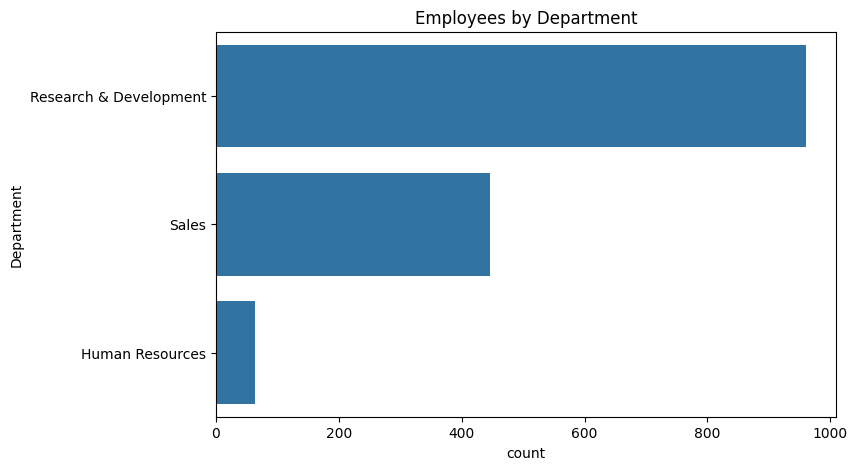

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='Department',
    data=df,
    order=df['Department'].value_counts().index
)

plt.title("Employees by Department")
plt.show()

#### Visualization 4

##### **Attrition Rate by Department**
##### The Sales department exhibits the highest attrition rate. This may indicate higher work pressure, performance targets, or job mobility within sales roles.

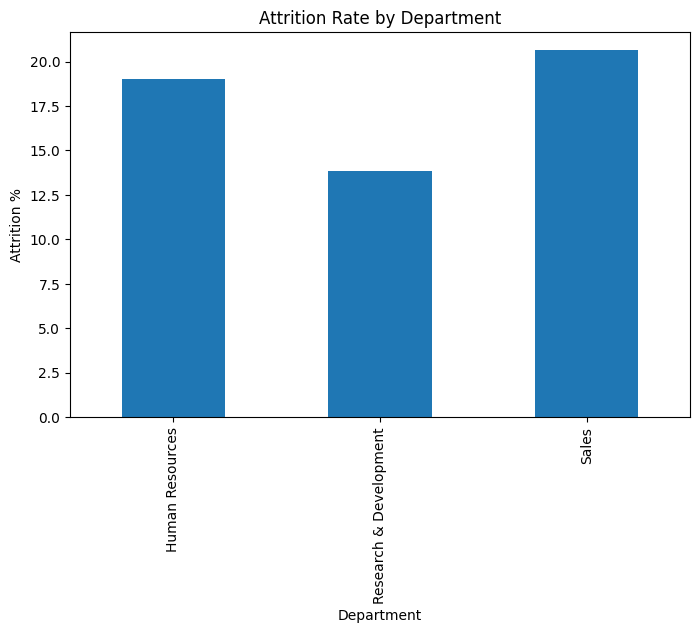

In [20]:
dept_attr = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
)*100

dept_attr['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Attrition %')
plt.title("Attrition Rate by Department")
plt.show()

#### Visualization 5

##### **Attrition by Gender**
##### Attrition rates between male and female employees are relatively similar, indicating that gender alone does not appear to be a major driver of attrition.

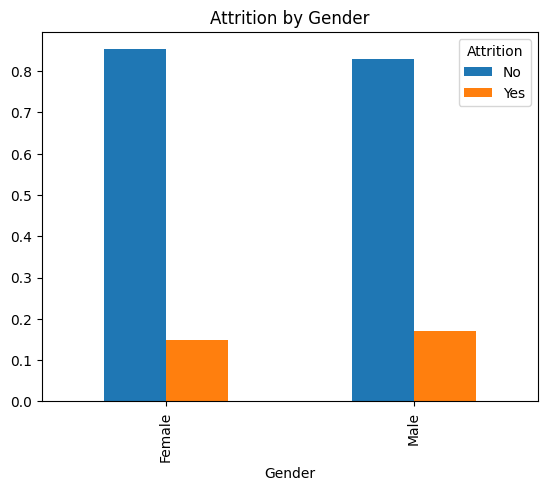

In [21]:
gender_attr = pd.crosstab(
    df['Gender'],
    df['Attrition'],
    normalize='index'
)

gender_attr.plot(kind='bar')
plt.title("Attrition by Gender")
plt.show()

#### Visualization 6

##### **Monthly Income vs Attrition**
##### Employees who left the company generally have lower monthly incomes compared to employees who stayed. Compensation may therefore play a role in employee retention.

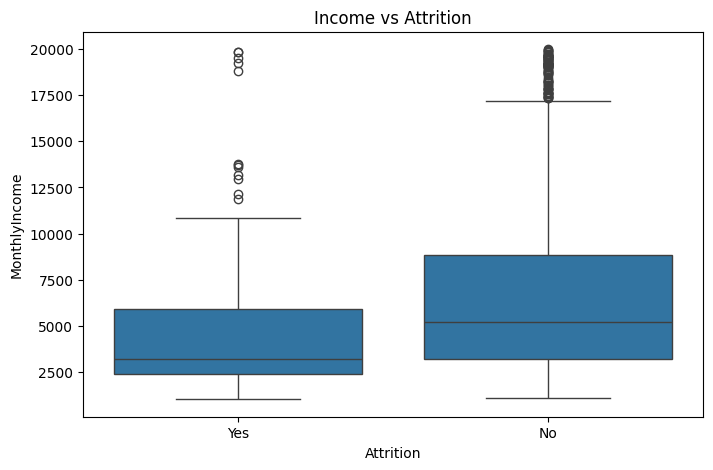

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Income vs Attrition")
plt.show()

#### Visualization 7

##### **Age vs Attrition**
##### Younger employees tend to leave the company more frequently than older employees. This may be due to career exploration, job switching, or seeking better opportunities.

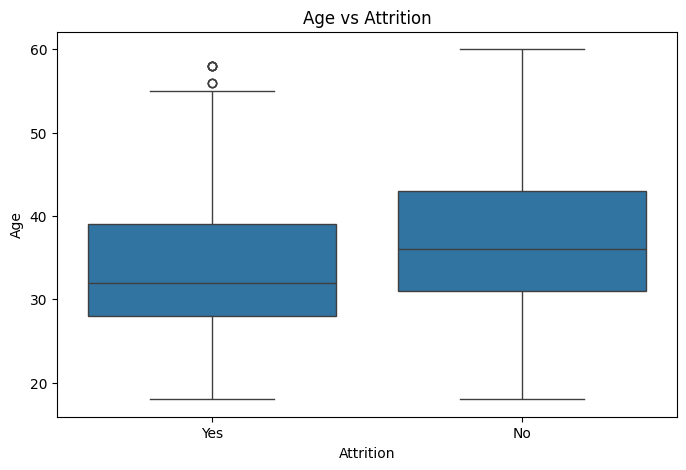

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.title("Age vs Attrition")
plt.show()

#### Visualization 8

##### **OverTime vs Attrition**
##### Employees working overtime show substantially higher attrition rates. Excessive workload and work-life imbalance may contribute to employee turnover.

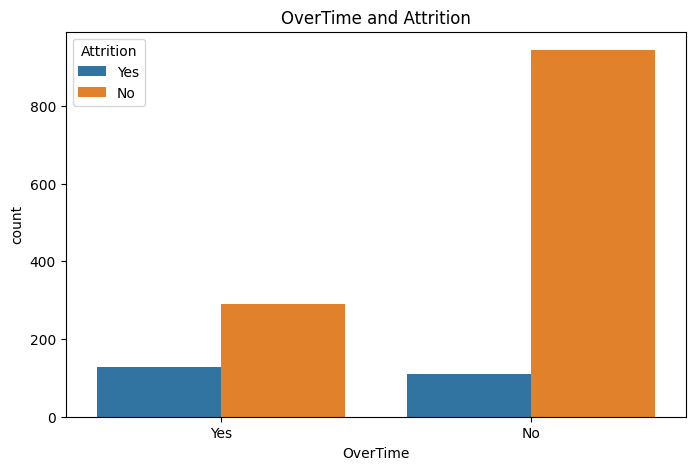

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)

plt.title("OverTime and Attrition")
plt.show()

#### Visualization 9

##### **Correlation Heatmap**
##### MonthlyIncome shows a strong positive correlation with JobLevel and TotalWorkingYears, indicating that experience and position level significantly influence salary.

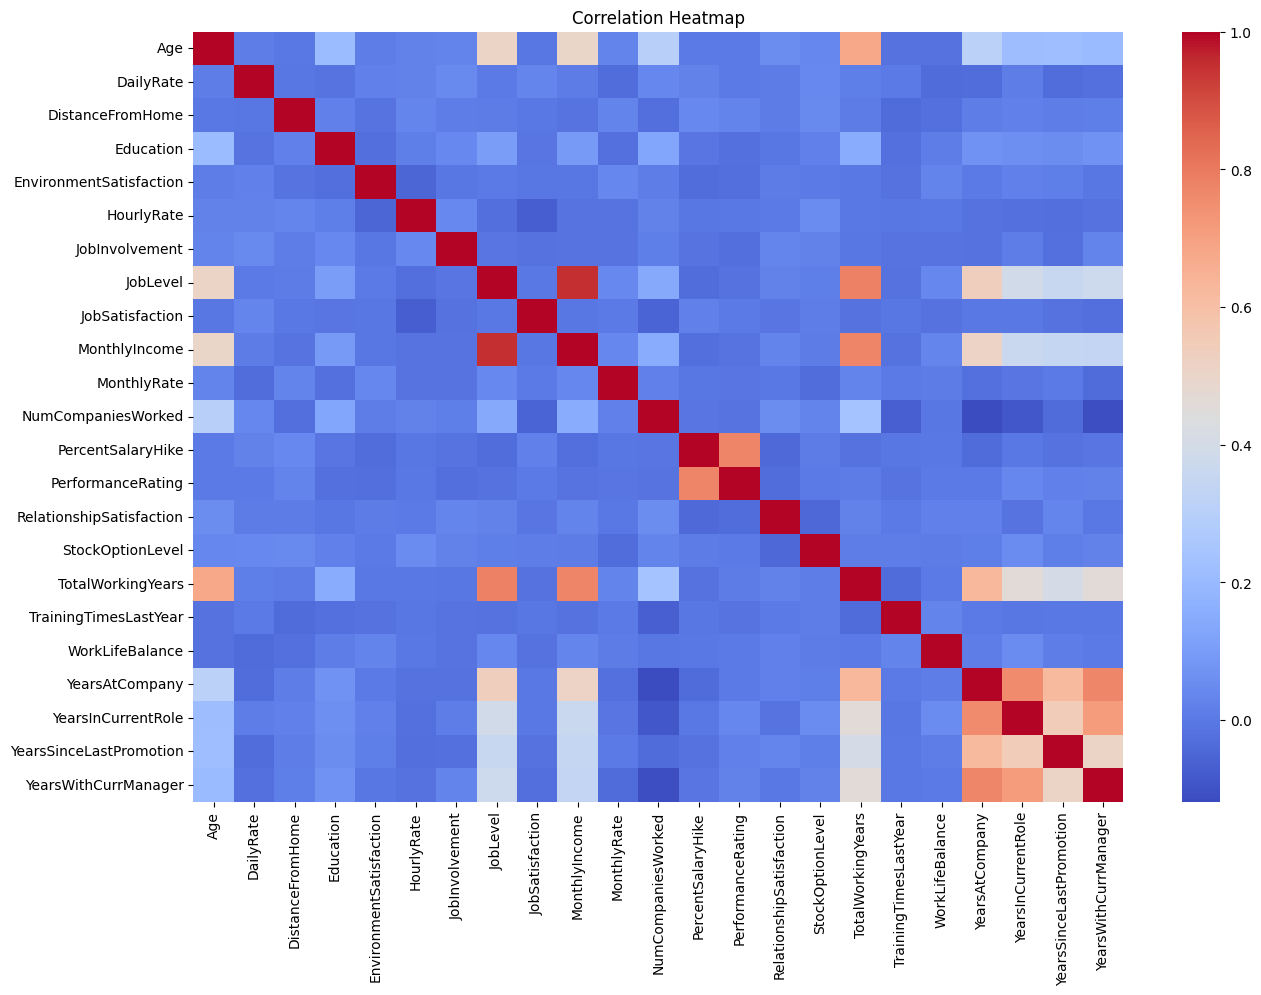

In [25]:
plt.figure(figsize=(15,10))
corr = df.select_dtypes(
    include=np.number
).corr()
sns.heatmap(
    corr,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

#### **Attrition Risk Score**

In [27]:
df['RiskScore'] = 0

df.loc[df['OverTime']=='Yes',
       'RiskScore'] += 3

df.loc[df['MonthlyIncome']
       <
       df['MonthlyIncome'].median(),
       'RiskScore'] += 2

df.loc[df['YearsAtCompany']<3,
       'RiskScore'] += 2

df.loc[df['Age']<30,
       'RiskScore'] += 1

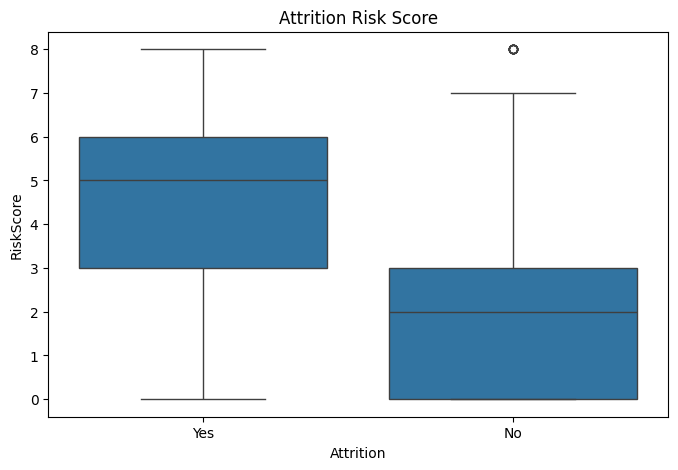

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='RiskScore',
    data=df
)

plt.title("Attrition Risk Score")
plt.show()

#### **Data Transformation**

##### **Feature and Target Split**

In [29]:
X = df.drop('Attrition',
            axis=1)

y = df['Attrition']

##### **Label Encoding Target**

In [30]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

##### **Label Encoding Binary Variables**

In [31]:
binary_cols = [
    'Gender',
    'OverTime'
]

for col in binary_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col])

##### **Train Test Split**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##### **One-Hot Encoding**

In [33]:
nominal_cols = X_train.select_dtypes(
    include='object'
).columns

X_train = pd.get_dummies(
    X_train,
    columns=nominal_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=nominal_cols,
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

##### **Feature Scaling**

In [34]:
num_cols = X_train.select_dtypes(
    include=np.number
).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

##### **Handle Class Imbalance**

In [35]:
class_counts = pd.Series(y).value_counts()

class_counts

,count
0,1233
1,237


In [36]:
imbalance_ratio = (
    class_counts[0] /
    class_counts[1]
)

print(
    "Imbalance Ratio:",
    imbalance_ratio
)

Imbalance Ratio: 5.2025316455696204


##### **Manual Class Weight Calculation**

In [37]:
n_samples = len(y)
n_classes = len(np.unique(y))
class_weights_manual = {}
for cls in np.unique(y):
    n_samples_per_class = np.sum(y == cls)
    weight = (
        n_samples /
        (n_classes * n_samples_per_class)
    )
    class_weights_manual[cls] = weight
print(class_weights_manual)

{np.int64(0): np.float64(0.5961070559610706), np.int64(1): np.float64(3.1012658227848102)}


#### **Verify Using sklearn**

In [38]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
print(weights)

[0.59610706 3.10126582]


##### The target variable is imbalanced because employees who stayed greatly outnumber employees who left. This imbalance can negatively affect machine learning models and therefore must be quantified.The dataset has an imbalance ratio of approximately 5.2:1. Employees who left represent a minority class. Calculated class weights can be used in future predictive models to improve minority-class recognition.

# **Final Summary**

### **Important Patterns Ovserved:**

1. Employees working overtime are significantly more likely to leave.
2. Lower-income employees exhibit higher attrition.
3. Younger employees experience greater turnover.
4. Sales department has the highest attrition rate.
5. Employees with shorter tenure are at greater risk of leaving.

### **Factors Most Related to Attrition:**

- OverTime
- MonthlyIncome
- Age
- YearsAtCompany
- Department

### **Employees Most at Risk:**

- Young employees
- Overtime workers
- Employees with low income
- Employees with shorter tenure
- Sales employees

### **Data Preparation:**

Original Shape: (1470, 35)

Final Shape: (1470, 31)

Class Imbalance Ratio: 5.2 : 1

Class Weights:
- Class 0 ≈ 0.596
- Class 1 ≈ 3.101